# **7 Days of Code: Python & Pandas 🐍📊**

## Sobre o desafio

O **#7DaysOfCode** é uma iniciativa da Alura que propõe um desafio prático por dia, durante 7 dias consecutivos. O objetivo é desenvolver habilidades reais de programação resolvendo problemas concretos, sem teoria em excesso, apenas prática.

Nesta edição, o foco é Python com Pandas, uma das combinações mais utilizadas no dia a dia de quem trabalha com análise e ciência de dados.

---
#

## Sobre este notebook

Este notebook foi desenvolvido por Fernanda Farias, Analista e Cientista de Dados.
Clique e conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/fernanda-fariasz/)

#
---

## Dia 1: Importando e preparando os dados

O primeiro dia do desafio trabalha uma etapa fundamental em qualquer projeto de dados: entender, importar e preparar os dados antes de qualquer análise.

Os dados utilizados são referentes aos empréstimos e ao acervo das bibliotecas da UFRN (Universidade Federal do Rio Grande do Norte), e o desafio propõe trabalhar apenas com os últimos 10 anos disponíveis.

### O que foi feito nessa etapa:

**1. Importação dos dados**

Os dados de empréstimos estavam distribuídos em múltiplos arquivos CSV em um repositório público no GitHub. Para evitar downloads manuais, os arquivos foram importados diretamente via API do GitHub. Já os dados do acervo estavam disponíveis em um único arquivo `.parquet`, importado diretamente pelo link bruto do repositório.

**2. Unificação dos DataFrames**

Como os empréstimos estavam fragmentados em vários arquivos (um por período), o primeiro passo foi consolidar todos em um único DataFrame, facilitando a manipulação e análise dos dados de forma centralizada.

**3. Limpeza dos dados**

Dados do mundo real raramente chegam perfeitos. Por isso, foram identificadas e tratadas linhas duplicadas e linhas completamente nulas em ambas as tabelas, garantindo a integridade dos dados antes de qualquer análise.

**4. Merge entre as tabelas**

Para enriquecer os dados de empréstimos com informações do acervo (como a biblioteca de origem do material e o tema ao qual ele pertence), as duas tabelas foram mescladas através da coluna de código de barras, que é a chave de relacionamento entre elas.


In [31]:
# 1. Importação dos dados

# Importação das bibliotecas utilizadas
import pandas as pd
import requests
import io


# Extração de dados de empréstimos
url_api = "https://api.github.com/repos/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/contents/Dia_1-Importando_dados/Datasets/dados_emprestimos"
dados_emprestimos = requests.get(url_api).json()
print(f"dados_emprestimos carregados")

# Extração dos dados dos exemplares
url_parquet = "https://raw.githubusercontent.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/main/Dia_1-Importando_dados/Datasets/dados_exemplares.parquet"
conteudo_parquet = requests.get(url_parquet).content
df_exemplares = pd.read_parquet(io.BytesIO(conteudo_parquet))
print(f"dados_exemplares.parquet carregados")

dados_emprestimos carregados
dados_exemplares.parquet carregados


In [32]:
# 2. Unificação dos dataframes de empréstimos

# Criação de uma lista com os empréstimos unificados
dfs = []
for arquivo in dados_emprestimos:
  if arquivo['name'].endswith('.csv'):
    conteudo = requests.get(arquivo['download_url']).content
    df = pd.read_csv(io.BytesIO(conteudo))
    dfs.append(df)
    print(f"{arquivo['name']}")

df_emprestimos = pd.concat(dfs, ignore_index=True)

emprestimos-20101.csv
emprestimos-20102.csv
emprestimos-20111.csv
emprestimos-20112.csv
emprestimos-20121.csv
emprestimos-20122.csv
emprestimos-20131.csv
emprestimos-20132.csv
emprestimos-20141.csv
emprestimos-20142.csv
emprestimos-20151.csv
emprestimos-20152.csv
emprestimos-20161.csv
emprestimos-20162.csv
emprestimos-20171.csv
emprestimos-20172.csv
emprestimos-20181.csv
emprestimos-20182.csv
emprestimos-20191.csv
emprestimos-20192.csv
emprestimos-20201.csv


In [33]:
# 3. Limpeza dos dados

df_emprestimos = df_emprestimos.drop_duplicates()
df_emprestimos = df_emprestimos.dropna(how='all')

print(f"Dados dos empréstimos após a limpeza:\n {df_emprestimos.shape}")

df_exemplares = df_exemplares.drop_duplicates()
df_exemplares = df_exemplares.dropna(how='all')

print(f"Dados dos exemplares após a limpeza:\n {df_exemplares.shape}")

Dados dos empréstimos após a limpeza:
 (2257981, 7)
Dados dos exemplares após a limpeza:
 (546237, 7)


In [34]:
# 4. Mesclagem dos dois dataframes

# Verificação dos nomes das colunas
print(f"Colunas de empréstimos: {df_emprestimos.columns.tolist()}")
print(f"Colunas de exemplares: {df_exemplares.columns.tolist()}")

# Unindo os dois arquivos
df_final = df_emprestimos.merge(df_exemplares)

print(f"Shape do dataframe final: {df_final.shape}")
print(f"Primeiros 10 registros: \n ")
df_final.head(10)

Colunas de empréstimos: ['id_emprestimo', 'codigo_barras', 'data_renovacao', 'data_emprestimo', 'data_devolucao', 'matricula_ou_siape', 'tipo_vinculo_usuario']
Colunas de exemplares: ['id_exemplar', 'codigo_barras', 'colecao', 'biblioteca', 'status_material', 'localizacao', 'registro_sistema']
Shape do dataframe final: (2072522, 13)
Primeiros 10 registros: 
 


,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,registro_sistema
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO,13259,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,630,4225
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2.008023e+09,ALUNO DE GRADUAÇÃO,70865,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,647,25009
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2.008112e+09,ALUNO DE PÓS-GRADUAÇÃO,195347,Acervo Circulante,Biblioteca Setorial Prof. Rodolfo Helinski - E...,REGULAR,640,75019
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,2.007211e+08,ALUNO DE GRADUAÇÃO,131639,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,609,44494
4,709688,2007027500,2010/01/19 15:59:26.464000000,2010/01/04 08:27:33.569000000,2010/02/03 13:06:30.662000000,2.009046e+09,ALUNO DE GRADUAÇÃO,225646,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,686,91736
5,709689,L157395,2010/01/19 15:59:26.447000000,2010/01/04 08:27:33.596000000,2010/02/03 13:06:43.125000000,2.009046e+09,ALUNO DE GRADUAÇÃO,57040,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,698,20943
6,709690,2007019312,NaN,2010/01/04 08:49:57.857000000,2010/01/13 09:58:25.443000000,2.007014e+08,ALUNO DE GRADUAÇÃO,225786,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,698,91962
7,709691,2008046357,2010/01/19 11:50:13.404000000,2010/01/04 09:02:30.576000000,2010/02/02 12:13:36.132000000,2.005075e+08,ALUNO DE GRADUAÇÃO,256537,Acervo Circulante,Biblioteca Setorial Bertha Cruz Enders - ­Esco...,REGULAR,645,110273
8,709692,L187962,NaN,2010/01/04 09:07:06.131000000,2010/06/22 18:55:04.000000000,2.004044e+08,ALUNO DE GRADUAÇÃO,143654,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,658,51005
9,709693,L192776,NaN,2010/01/04 09:07:06.159000000,2010/06/22 18:54:46.000000000,2.004044e+08,ALUNO DE GRADUAÇÃO,159348,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,697,59235


## Dia 2: Limpeza e manipulação dos dados

O segundo dia do desafio foca em uma etapa igualmente essencial em qualquer projeto de dados: limpar, transformar e enriquecer os dados para que façam sentido no contexto da análise.

Em bibliotecas, os itens do acervo são organizados pela **CDU (Classificação Decimal Universal)**, um sistema que classifica os materiais por tema através de códigos numéricos: de 000 a 999. Entender essa classificação é fundamental para responder perguntas como: quais temas são mais emprestados? Quais têm menor procura?

### O que foi feito nessa etapa:

**1. Exclusão de coluna irrelevante**

A coluna `registro_sistema` não contribui para as análises propostas pelo desafio e foi removida do DataFrame para simplificar a estrutura dos dados.

**2. Conversão da matrícula para string**

A coluna `matricula_ou_siape` estava armazenada como número, o que não faz sentido para um identificador. Foi convertida para o formato string, tornando-a mais legível e adequada para o contexto.

**3. Criação da coluna de classe CDU**

Com base nos códigos numéricos da coluna `localizacao`, foi criada uma nova coluna `classe_cdu` que mapeia cada material à sua respectiva classe geral da CDU. Isso permitirá análises temáticas nos próximos dias.

> ⚠️ **Observação:** Durante o merge realizado no Dia 1, 189.257 registros de empréstimos não encontraram correspondência no acervo e foram perdidos. O DataFrame passou de 2.261.779 para 2.072.522 linhas. Esses registros podem corresponder a materiais que foram desativados ou removidos do acervo ao longo do tempo.

In [35]:
# 1. Exclusão de coluna irrelevante
df_final = df_final.drop(columns=['registro_sistema'])

# 2. Conversão matrícula para String
df_final['matricula_ou_siape'] = df_final['matricula_ou_siape'].astype(str)

# Criação da coluna de classe CDU
def classificar_cdu(localizacao):
  try:
    codigo = float(localizacao)
    if 0 <= codigo <= 99:
      return 'Generalidades. Ciência e Conhecimento'
    elif 100 <= codigo <= 199:
      return 'Filosofia e Psicologia'
    elif 200 <= codigo <= 299:
      return 'Religião'
    elif 300 <= codigo <= 399:
      return 'Ciências Sociais'
    elif 400 <= codigo <= 499:
      return 'Classe Vaga. Provisoriamente não ocupada'
    elif 500 <= codigo <= 599:
      return 'Matemática e Ciências Naturais'
    elif 600 <= codigo <= 699:
      return 'Ciências Aplicadas'
    elif 700 <= codigo <= 799:
      return 'Belas Artes'
    elif 800 <= codigo <= 899:
      return 'Linguagem. Língua. Linguística'
    elif 900 <= codigo <= 999:
      return 'Geografia. Biografia. História'
    else:
      return 'Não Classificado'
  except:
    return 'Não Classificado'

df_final['classe_cdu'] = df_final['localizacao'].apply(classificar_cdu)

In [36]:
# Verificando a saída dos dados

print(f"Shape final: \n{df_final.shape}")
print(f"\nTipos de dados: \n{df_final.dtypes}")
print(f"\nDistribuição das classes CDU: \n{df_final['classe_cdu'].value_counts()}")

Shape final: 
(2072522, 13)

Tipos de dados: 
id_emprestimo            int64
codigo_barras           object
data_renovacao          object
data_emprestimo         object
data_devolucao          object
matricula_ou_siape      object
tipo_vinculo_usuario    object
id_exemplar              int64
colecao                 object
biblioteca              object
status_material         object
localizacao              int64
classe_cdu              object
dtype: object

Distribuição das classes CDU: 
classe_cdu
Ciências Aplicadas                       1425473
Ciências Sociais                          369536
Matemática e Ciências Naturais             68744
Generalidades. Ciência e Conhecimento      62521
Religião                                   62295
Filosofia e Psicologia                     60563
Geografia. Biografia. História              7989
Belas Artes                                 7911
Linguagem. Língua. Linguística              7490
Name: count, dtype: int64


## Dia 3: Explorando os dados

O terceiro dia do desafio marca o início da análise exploratória dos dados.
Nesta etapa, investigamos como os empréstimos se comportam ao longo do tempo,
respondendo a perguntas práticas da diretoria da biblioteca sobre sazonalidade
e distribuição de demanda.

O empréstimo de materiais é um dos principais indicadores de uso de uma
biblioteca. Entender *quando* os empréstimos acontecem — por ano, por mês
ou por hora do dia — é essencial para o planejamento de recursos humanos
e infraestrutura.

### O que foi feito nessa etapa:

**1. Evolução dos empréstimos por ano**

Verificamos a quantidade total de exemplares emprestados a cada ano para
entender se a demanda está crescendo, diminuindo ou se mantendo estável
ao longo do tempo.

**2. Distribuição dos empréstimos por mês**

Geramos uma tabela e um gráfico com o total de exemplares emprestados por
mês, para identificar os períodos de maior e menor demanda ao longo do ano
— informação essencial para o planejamento de férias e atividades internas.

**3. Distribuição dos empréstimos por hora do dia**

Analisamos em quais horários do dia se concentra a maior parte dos
empréstimos, para apoiar a programação diária das atividades da biblioteca.

> **Observação:** Os dados de 2020 apresentam queda abrupta em relação
> aos anos anteriores, reflexo do fechamento das bibliotecas físicas durante
> a pandemia de COVID-19.

In [37]:
import matplotlib.pyplot as plt

# Converção de datas para Datetime
df_final['data_emprestimo'] = pd.to_datetime(df_final['data_emprestimo'])

# Extração de ano, mês e hora
df_final['ano'] = df_final['data_emprestimo'].dt.year
df_final['mes'] = df_final['data_emprestimo'].dt.month
df_final['hora'] = df_final['data_emprestimo'].dt.hour

print("Datas convertidas com sucesso!")
print(df_final[['data_emprestimo', 'ano', 'mes', 'hora']].head(10))

Datas convertidas com sucesso!
          data_emprestimo   ano  mes  hora
0 2010-01-04 07:44:10.721  2010    1     7
1 2010-01-04 07:44:10.750  2010    1     7
2 2010-01-04 08:08:44.081  2010    1     8
3 2010-01-04 08:24:21.284  2010    1     8
4 2010-01-04 08:27:33.569  2010    1     8
5 2010-01-04 08:27:33.596  2010    1     8
6 2010-01-04 08:49:57.857  2010    1     8
7 2010-01-04 09:02:30.576  2010    1     9
8 2010-01-04 09:07:06.131  2010    1     9
9 2010-01-04 09:07:06.159  2010    1     9


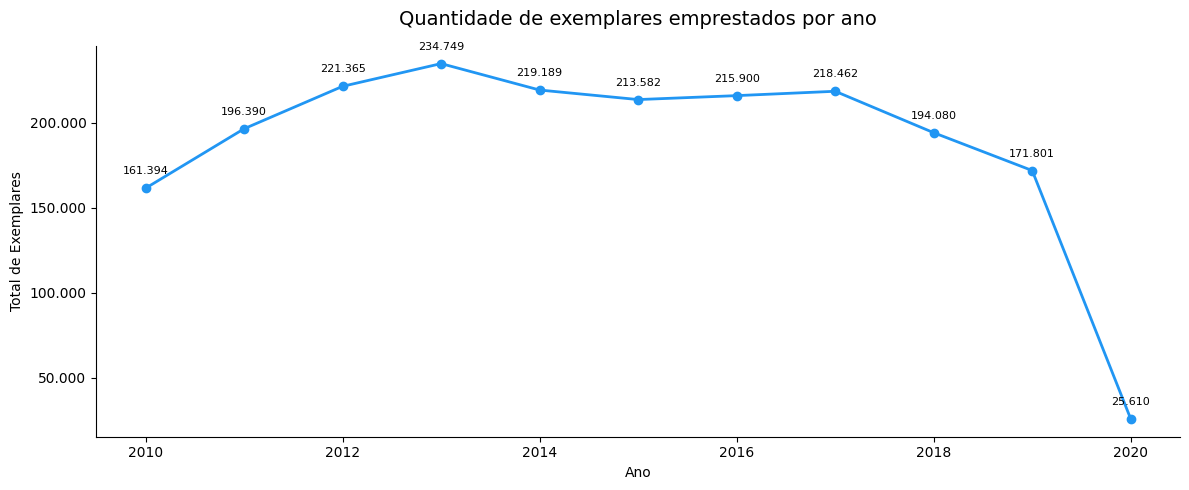

 ano  total_exemplares
2010            161394
2011            196390
2012            221365
2013            234749
2014            219189
2015            213582
2016            215900
2017            218462
2018            194080
2019            171801
2020             25610


In [38]:
# Agrupa os dados de exemplares emprestados pro ano, e renomeia com nomes mais descritivos
emprestimos_por_ano = df_final.groupby('ano')['id_exemplar'].count().reset_index()
emprestimos_por_ano.columns = ['ano', 'total_exemplares']

# Cria a figura e plota o gráfico de linhas
fig, graf = plt.subplots(figsize=(12, 5))

graf.plot(emprestimos_por_ano['ano'],
         emprestimos_por_ano['total_exemplares'],
         marker='o', color='#2196F3', linewidth=2)

# Definição e formatação de título, rótulos dos eixos e valores
graf.set_title('Quantidade de exemplares emprestados por ano', fontsize = 14, pad = 15)
graf.set_xlabel('Ano')
graf.set_ylabel('Total de Exemplares')
graf.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

# Adiciona o valor numérico em cada ponto do gráfico
for _, row in emprestimos_por_ano.iterrows():
  graf.annotate(f"{int(row['total_exemplares']):,}".replace(',','.'),
                xy = (row['ano'], row['total_exemplares']),
                xytext = (0,10), textcoords = 'offset points',
                ha = 'center', fontsize = 8)

# Remoção de bordas e juste de espaçamentos
graf.spines['top'].set_visible(False)
graf.spines['right'].set_visible(False)
plt.tight_layout()

# Mostra gráfico e tabela
plt.show()
print(emprestimos_por_ano.to_string(index=False))

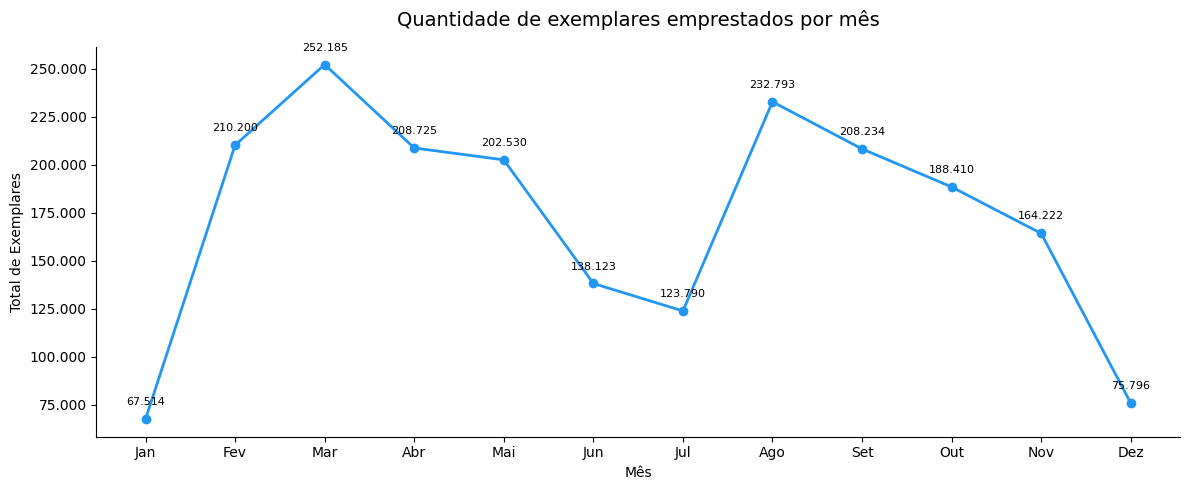

mes_nome  total_exemplares
     Jan             67514
     Fev            210200
     Mar            252185
     Abr            208725
     Mai            202530
     Jun            138123
     Jul            123790
     Ago            232793
     Set            208234
     Out            188410
     Nov            164222
     Dez             75796


In [39]:
# Dicionário dos meses em números e nomes
meses_nomes = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

# Agrupa por mês, conta os exemplares e cria coluna com nome do mês
emprestimos_por_mes = df_final.groupby('mes')['id_exemplar'].count().reset_index()
emprestimos_por_mes.columns = ['mes', 'total_exemplares']
emprestimos_por_mes['mes_nome'] = emprestimos_por_mes['mes'].map(meses_nomes)

# Cria a figura e plota o gráfico de linhas
fig, graf = plt.subplots(figsize=(12,5))

graf.plot(emprestimos_por_mes['mes_nome'],
          emprestimos_por_mes['total_exemplares'],
          marker='o', color='#2196F3', linewidth=2)

# Definição e formatação de título, eixos e valores
graf.set_title('Quantidade de exemplares emprestados por mês', fontsize = 14, pad = 15)
graf.set_xlabel('Mês')
graf.set_ylabel('Total de Exemplares')
graf.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))

# Adiciona o valor numérico em cada ponto do gráfico
for _, row in emprestimos_por_mes.iterrows():
  graf.annotate(f"{int(row['total_exemplares']):,}".replace(',','.'),
                xy = (row['mes_nome'], row['total_exemplares']),
                xytext = (0,10), textcoords = 'offset points',
                ha= 'center', fontsize = 8)

# Remoção de bordas e juste de espaçamentos
graf.spines['top'].set_visible(False)
graf.spines['right'].set_visible(False)
plt.tight_layout()

# Mostra gráfico e tabela
plt.show()
print(emprestimos_por_mes[['mes_nome', 'total_exemplares']].to_string(index=False))

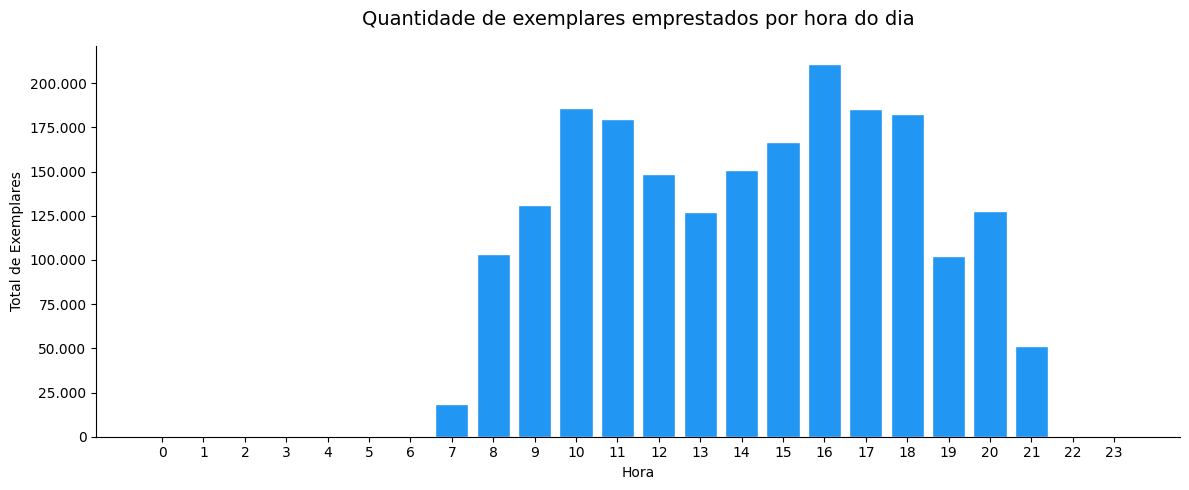

 hora  total_exemplares
    0                17
    6                14
    7             18777
    8            103416
    9            131273
   10            185839
   11            180048
   12            148754
   13            126987
   14            150876
   15            166672
   16            210655
   17            185340
   18            182520
   19            102129
   20            127716
   21             51191
   22               247
   23                51


In [40]:
# Agrupa os dados de exemplares emprestados pro hora do dia
emprestimos_por_hora = df_final.groupby('hora')['id_exemplar'].count().reset_index()
emprestimos_por_hora.columns = ['hora', 'total_exemplares']

# Cria a figura e plota o gráfico de barras
fig, graf = plt.subplots(figsize=(12,5))

graf.bar(emprestimos_por_hora['hora'],
         emprestimos_por_hora['total_exemplares'],
         color='#2196F3', edgecolor='white')

# Definição e formatação de título, eixos e valores
graf.set_title('Quantidade de exemplares emprestados por hora do dia', fontsize = 14, pad = 15)
graf.set_xlabel('Hora')
graf.set_ylabel('Total de Exemplares')
graf.set_xticks(range(0,24))
graf.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))

# Remoção de bordas e juste de espaçamentos
graf.spines['top'].set_visible(False)
graf.spines['right'].set_visible(False)
plt.tight_layout()

# Mostra gráfico e tabela
plt.show()
print(emprestimos_por_hora[['hora', 'total_exemplares']].to_string(index=False))

### Análise 1: Empréstimos por ano

A quantidade de empréstimos cresceu progressivamente entre 2010 e 2013,
atingindo o pico em 2013 com 234.749 exemplares emprestados. A partir de
2014, observa-se uma tendência de queda gradual, que se intensifica em 2019
e 2020. Vale destacar que os dados de 2020 (25.610 empréstimos) refletem
o impacto da pandemia de COVID-19, que forçou o fechamento das bibliotecas
físicas em março daquele ano, o que pode explicar a queda abrupta em relação
aos anos anteriores caso a escola não tenha realizado nenhuma ação que viabilizasse e incentivasse o emprestimos dos livros.

### Análise 2: Empréstimos por mês

A suspeita interna de que março e setembro seriam os meses de maior demanda
se confirmou parcialmente. **Março** é de fato o mês com maior número de
empréstimos (252.185), seguido de **agosto** (232.793) e **fevereiro**
(210.200). Setembro aparece em quinto lugar, com 208.234 empréstimos.

O padrão faz sentido considerando o calendário acadêmico: os picos coincidem
com o início dos semestres letivos (março e agosto), quando a demanda por
materiais bibliográficos é naturalmente maior. Já os meses de menor demanda
são **janeiro** (67.514) e **dezembro** (75.796), períodos de recesso e
férias universitárias.

> Portanto, os meses de janeiro e dezembro são opções interessantes para programar férias dos colaboradores e atividades internas que não envolvam atendimento ao usuário. Julho (123.790) também apresenta
queda relevante, coincidindo com o recesso entre semestres.

### Análise 3: Empréstimos por hora do dia

A biblioteca concentra sua demanda no período da tarde, com pico às **16h**
(210.655 empréstimos). O movimento começa a crescer a partir das 8h,
mantém-se elevado entre 10h e 18h, e cai drasticamente após as 19h.

Praticamente não há empréstimos entre 0h e 6h, o que indica que o sistema
registra transações apenas em horário de funcionamento da biblioteca.

> Como recomendação, entende-se que os melhores horários para alocar atividades internas que não sejam de atendimento ao usuário seriam o início da manhã (até 9h) e o final da noite (a partir das 19h), quando a demanda é significativamente menor.